# Comparative Analysis of GAN Loss Functions
## Visualization Notebook — 5 Loss Functions

**Author:** Sanskar Kushwah | NIT Srinagar  
**Datasets:** CIFAR-10 · EuroSAT · CheXpert  
**Models:** Standard GAN · LSGAN · WGAN · WGAN-GP · Hinge Loss

---
| Cell | Plot | Description |
|------|------|-------------|
| 2 | Setup | Imports, palette, helpers |
| 3 | Load Data | Read CSV files |
| 4 | Plot 01 | FID curves over epochs — CIFAR-10 |
| 5 | Plot 02 | FID curves over epochs — EuroSAT |
| 6 | Plot 03 | G & D Loss curves (5 subplots) — CIFAR-10 |
| 7 | Plot 04 | G & D Loss curves (5 subplots) — EuroSAT |
| 8 | Plot 05 | Mode Variance over epochs — CIFAR-10 |
| 9 | Plot 06 | Mode Variance over epochs — EuroSAT |
| 10 | Plot 07 | Best FID bar chart — CIFAR-10 & EuroSAT |
| 11 | Plot 08 | Mode Variance bar — CIFAR-10 vs EuroSAT |
| 12 | Plot 09 | Quality–Diversity scatter (FID vs ModeVar) |
| 13 | Run All | Regenerate all plots at once |

> **CSV files required** (put them in a `csv/` folder):
> - `csv/cifer_all_6.csv`
> - `csv/euro_5229_graph.csv`

In [1]:
# Cell 1 — Install dependencies (run once)
import subprocess, sys
for p in ["numpy", "pandas", "matplotlib", "scipy"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])
print("All packages ready.")

All packages ready.


In [2]:
# Cell 2 — Setup: imports, palette, helpers
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import uniform_filter1d

warnings.filterwarnings("ignore")
os.makedirs("plots", exist_ok=True)

# ── Global plot style ─────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.22,
    "grid.linestyle":     "--",
    "grid.linewidth":     0.6,
    "figure.dpi":         120,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.15,
    "axes.titlesize":     13,
    "axes.labelsize":     11,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
})

# ── Color palette — 5 models only ────────────────────────────────────────────
PAL = {
    "STANDARD": "#E24B4A",   # red
    "LSGAN":    "#EF9F27",   # amber
    "WGAN":     "#378ADD",   # blue
    "WGANGP":   "#1D9E75",   # teal/green
    "HINGE":    "#7F77DD",   # purple
}
LABELS = {
    "STANDARD": "Standard GAN",
    "LSGAN":    "LSGAN",
    "WGAN":     "WGAN",
    "WGANGP":   "WGAN-GP",
    "HINGE":    "Hinge Loss",
}
ORDER = list(PAL.keys())

def col(key):  return PAL[key]
def lbl(key):  return LABELS[key]

def smooth(arr, w=5):
    arr = np.array(arr, dtype=float)
    return uniform_filter1d(arr, size=min(w, len(arr)))

def save_fig(fig, name):
    path = f"plots/{name}.png"
    fig.savefig(path)
    print(f"  saved → {path}")

print("Setup complete.")

Setup complete.


In [3]:
# Cell 3 — Load CSV data
CIFAR   = pd.read_csv("csv/cifer_all_6.csv")
EURO150 = pd.read_csv("csv/euro_5229_graph.csv")

# Keep only the 5 main loss functions
CIFAR   = CIFAR[CIFAR["Experiment"].isin(ORDER)].reset_index(drop=True)
EURO150 = EURO150[EURO150["Experiment"].isin(ORDER)].reset_index(drop=True)

def get_col(df, exp, col_name):
    return df[df["Experiment"] == exp][col_name].tolist()

def get_fid(df, exp):
    sub = df[(df["Experiment"] == exp) & df["FID"].notna()]
    return sub["Epoch"].tolist(), sub["FID"].tolist()

print("CIFAR-10  experiments:", CIFAR["Experiment"].unique().tolist())
print("EuroSAT   experiments:", EURO150["Experiment"].unique().tolist())

CIFAR-10  experiments: ['STANDARD', 'LSGAN', 'WGAN', 'WGANGP', 'HINGE']
EuroSAT   experiments: ['STANDARD', 'LSGAN', 'WGAN', 'WGANGP', 'HINGE']


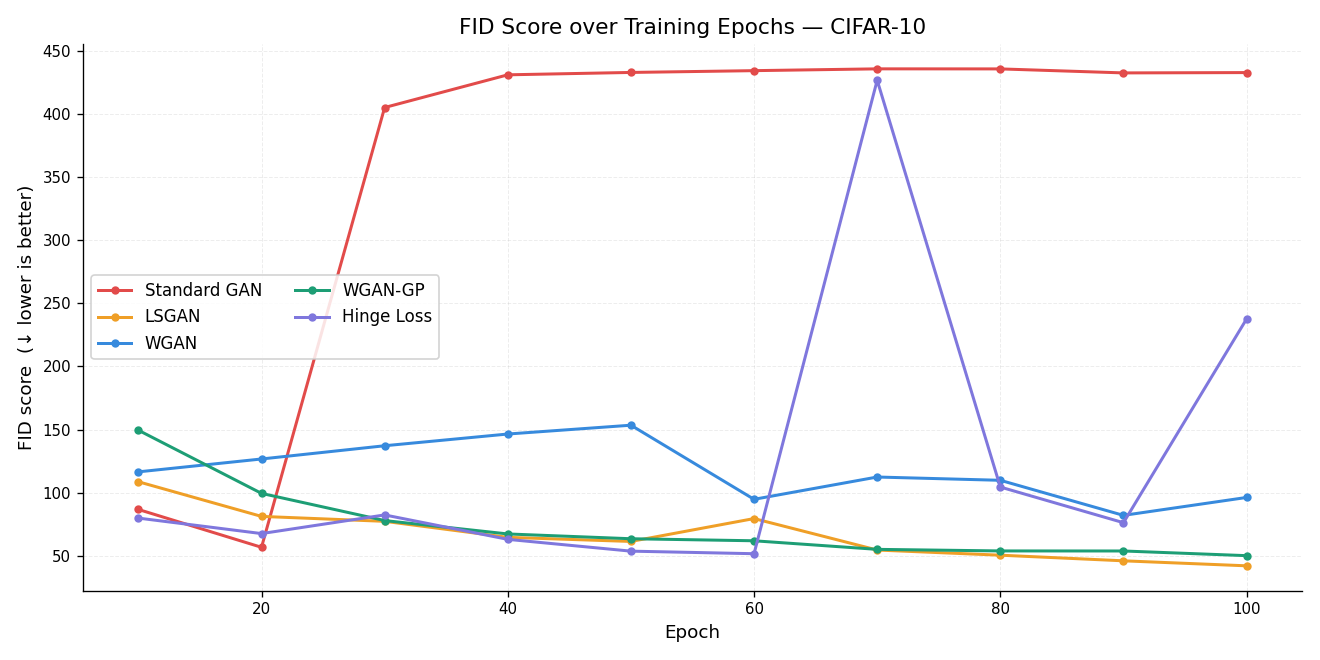

  saved → plots/01_fid_curves_cifar10.png


In [4]:
# Plot 01 — FID curves over epochs · CIFAR-10
fig, ax = plt.subplots(figsize=(11, 5.5))

for key in ORDER:
    ep, fid = get_fid(CIFAR, key)
    ax.plot(ep, fid, color=col(key), lw=1.8,
            marker="o", markersize=4, label=lbl(key))

ax.set_xlabel("Epoch")
ax.set_ylabel("FID score  (↓ lower is better)")
ax.set_title("FID Score over Training Epochs — CIFAR-10")
ax.legend(fontsize=10, ncol=2, framealpha=0.85)
plt.tight_layout()
plt.show()
save_fig(fig, "01_fid_curves_cifar10")

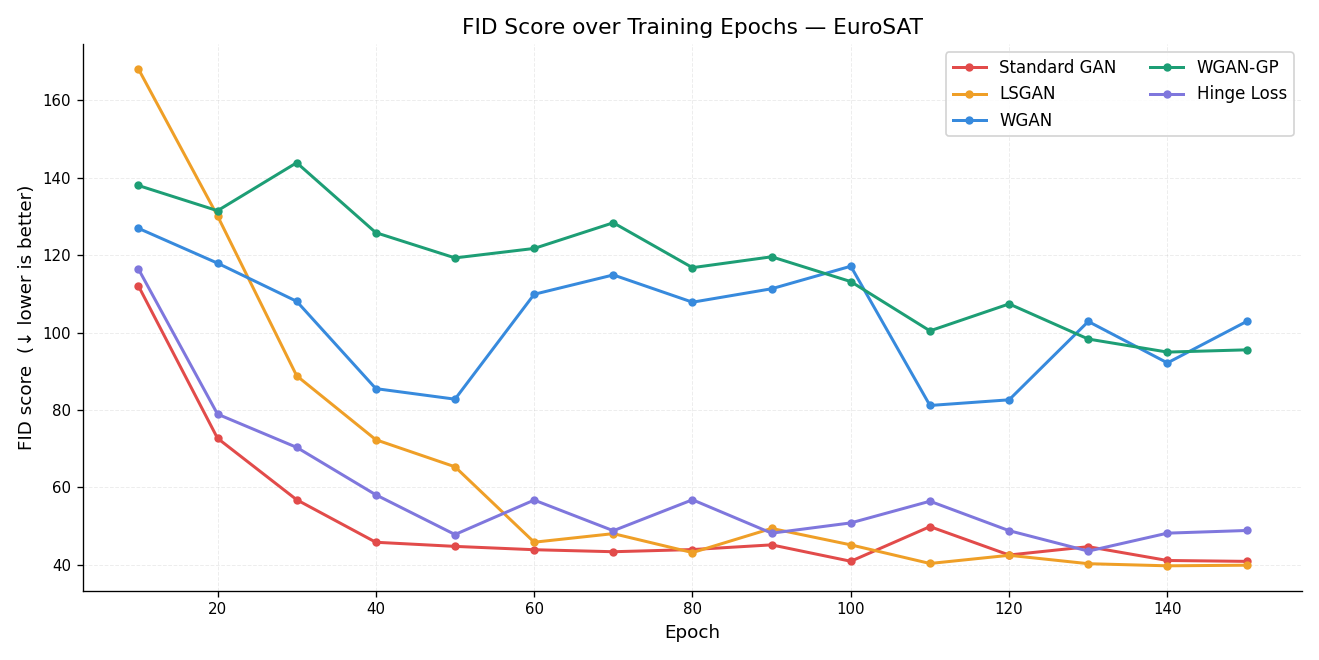

  saved → plots/02_fid_curves_eurosat.png


In [5]:
# Plot 02 — FID curves over epochs · EuroSAT
fig, ax = plt.subplots(figsize=(11, 5.5))

for key in ORDER:
    ep, fid = get_fid(EURO150, key)
    ax.plot(ep, fid, color=col(key), lw=1.8,
            marker="o", markersize=4, label=lbl(key))

ax.set_xlabel("Epoch")
ax.set_ylabel("FID score  (↓ lower is better)")
ax.set_title("FID Score over Training Epochs — EuroSAT")
ax.legend(fontsize=10, ncol=2, framealpha=0.85)
plt.tight_layout()
plt.show()
save_fig(fig, "02_fid_curves_eurosat")

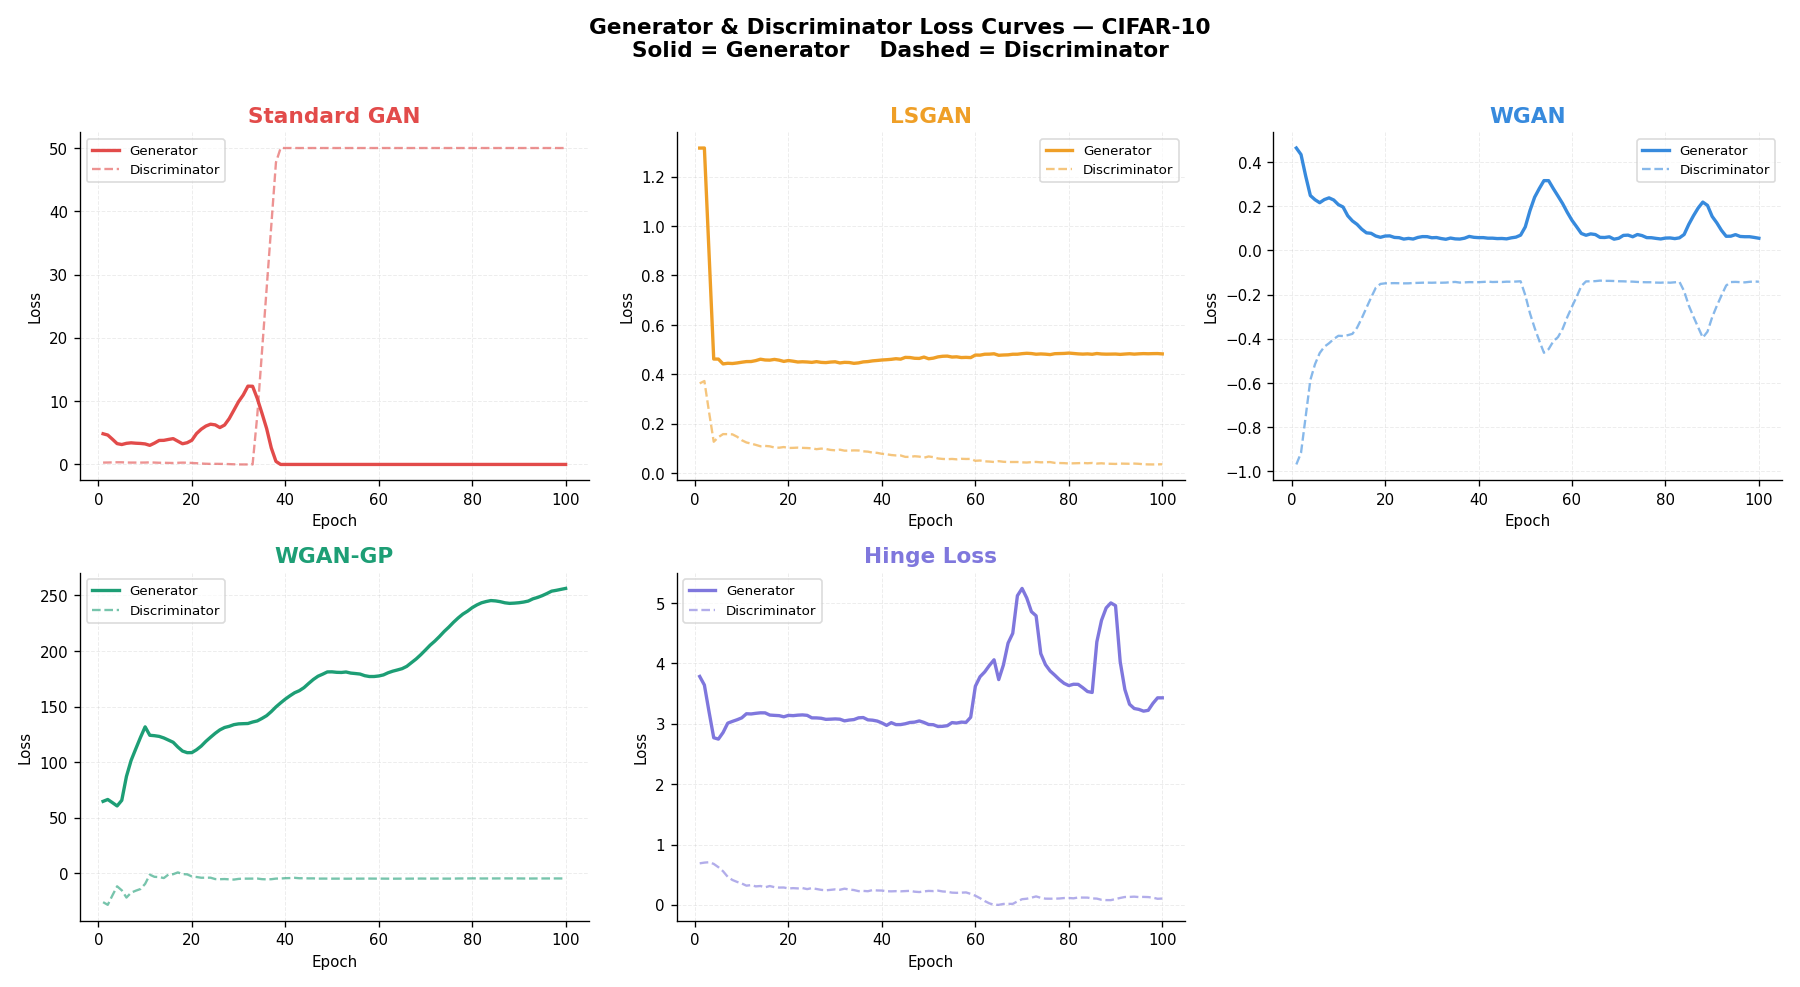

  saved → plots/03_loss_curves_cifar10.png


In [6]:
# Plot 03 — Generator & Discriminator Loss Curves · CIFAR-10
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, key in zip(axes[:5], ORDER):
    ep   = CIFAR[CIFAR["Experiment"] == key]["Epoch"].tolist()
    gl_s = smooth(get_col(CIFAR, key, "G_Loss"))
    dl_s = smooth(get_col(CIFAR, key, "D_Loss"))

    ax.plot(ep, gl_s, color=col(key), lw=2.0, label="Generator")
    ax.plot(ep, dl_s, color=col(key), lw=1.4, ls="--", alpha=0.6,
            label="Discriminator")
    ax.set_title(lbl(key), color=col(key), fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel("Loss",  fontsize=9)
    ax.legend(fontsize=8, framealpha=0.7)

# Hide the 6th (empty) subplot
axes[5].set_visible(False)

fig.suptitle("Generator & Discriminator Loss Curves — CIFAR-10\n"
             "Solid = Generator    Dashed = Discriminator",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
save_fig(fig, "03_loss_curves_cifar10")

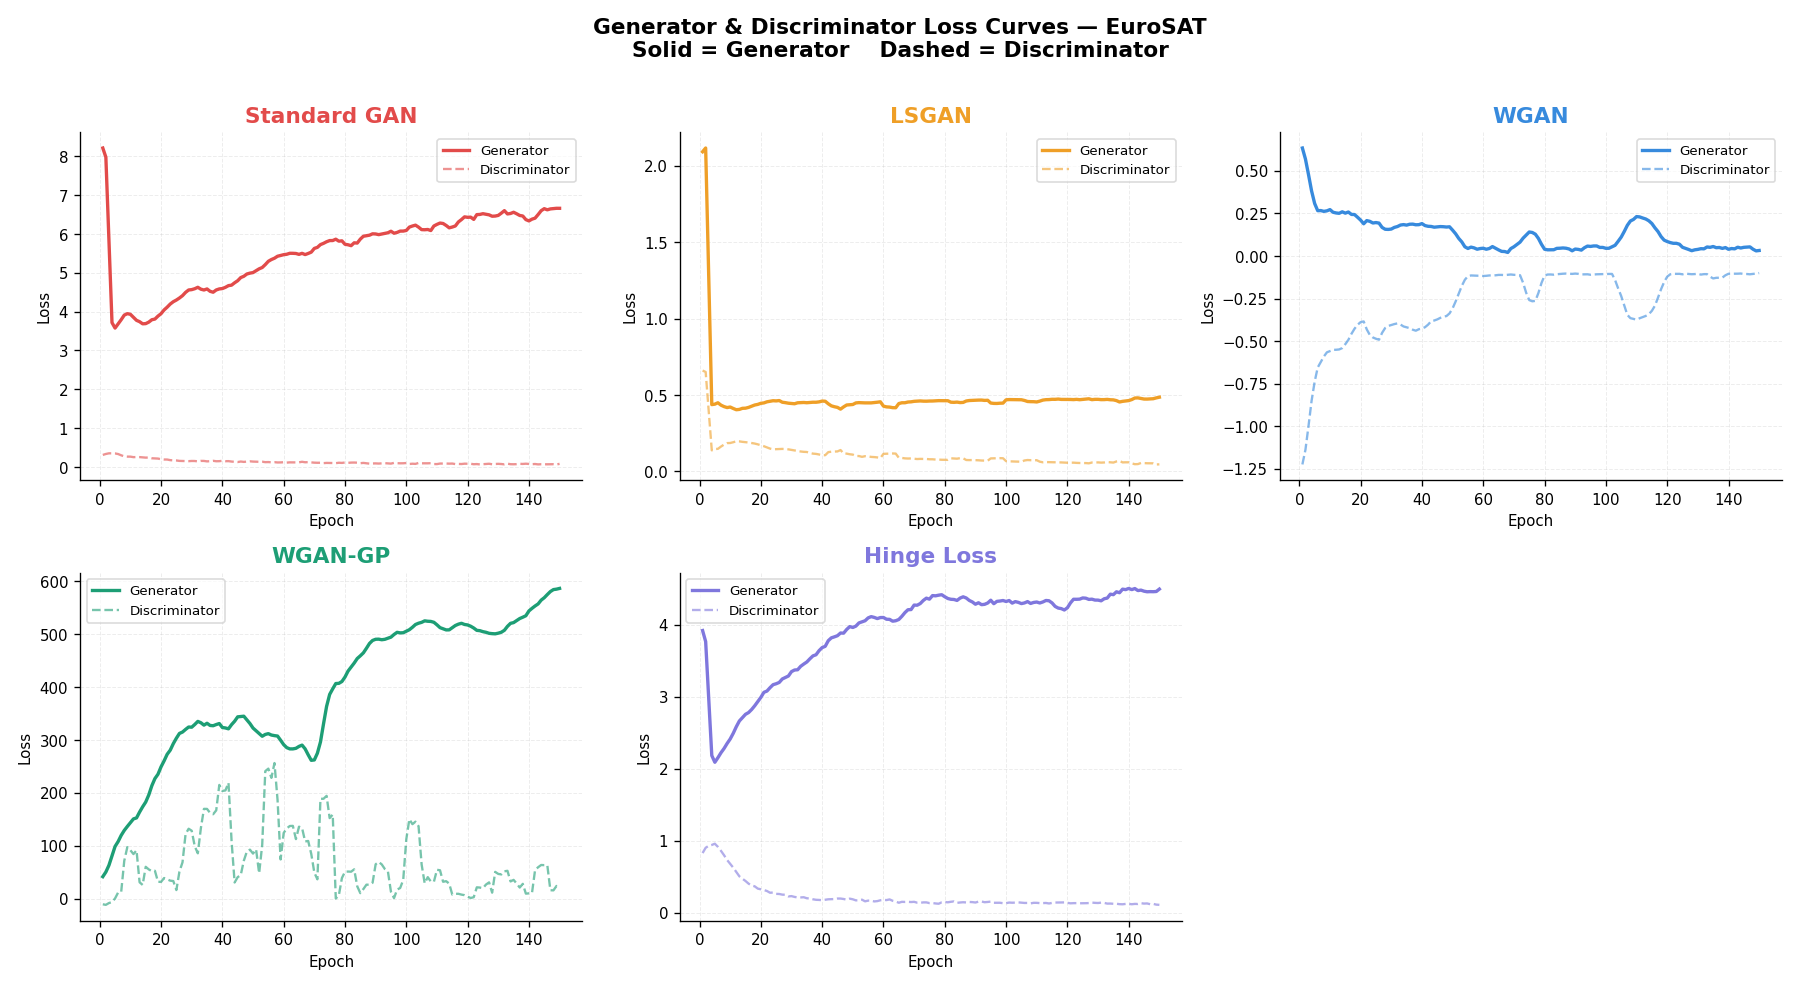

  saved → plots/04_loss_curves_eurosat.png


In [7]:
# Plot 04 — Generator & Discriminator Loss Curves · EuroSAT
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, key in zip(axes[:5], ORDER):
    sub  = EURO150[EURO150["Experiment"] == key]
    ep   = sub["Epoch"].tolist()
    gl_s = smooth(sub["G_Loss"].tolist())
    dl_s = smooth(sub["D_Loss"].tolist())

    ax.plot(ep, gl_s, color=col(key), lw=2.0, label="Generator")
    ax.plot(ep, dl_s, color=col(key), lw=1.4, ls="--", alpha=0.6,
            label="Discriminator")
    ax.set_title(lbl(key), color=col(key), fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel("Loss",  fontsize=9)
    ax.legend(fontsize=8, framealpha=0.7)

axes[5].set_visible(False)

fig.suptitle("Generator & Discriminator Loss Curves — EuroSAT\n"
             "Solid = Generator    Dashed = Discriminator",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
save_fig(fig, "04_loss_curves_eurosat")

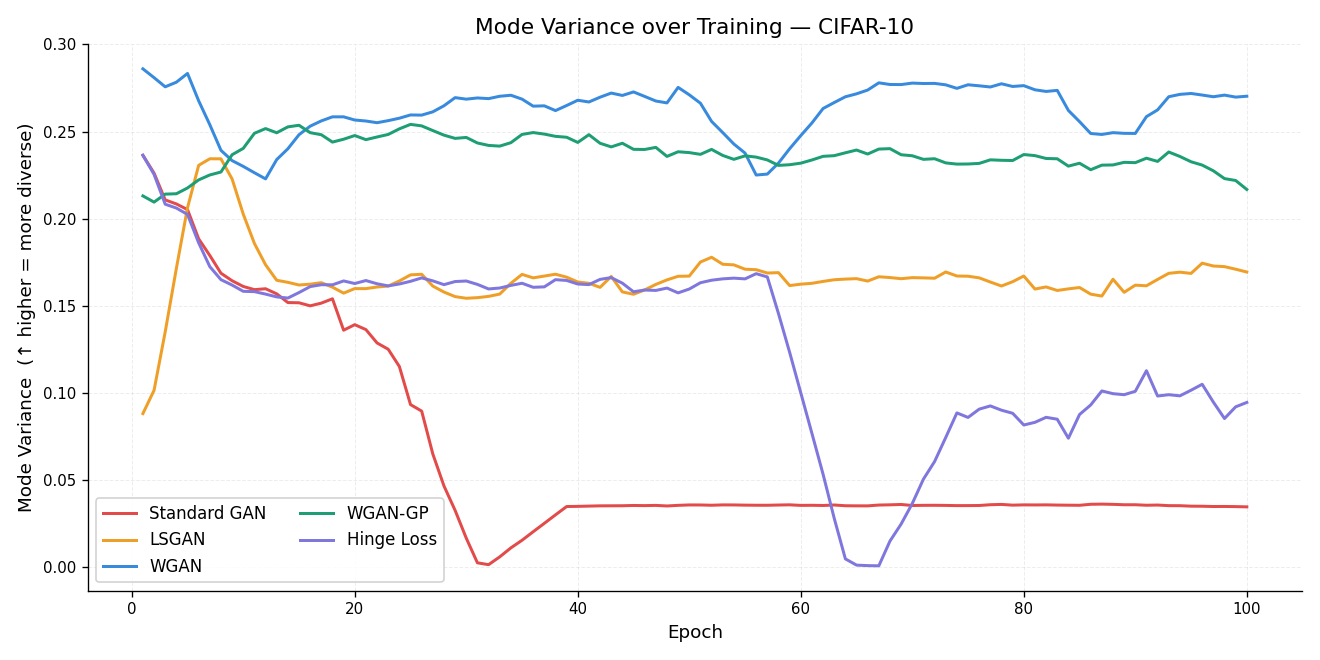

  saved → plots/05_modevar_curves_cifar10.png


In [8]:
# Plot 05 — Mode Variance over epochs · CIFAR-10
fig, ax = plt.subplots(figsize=(11, 5.5))

for key in ORDER:
    ep = CIFAR[CIFAR["Experiment"] == key]["Epoch"].tolist()
    mv = smooth(get_col(CIFAR, key, "ModeVar"), w=7)
    ax.plot(ep, mv, color=col(key), lw=1.8, label=lbl(key))

ax.set_xlabel("Epoch")
ax.set_ylabel("Mode Variance  (↑ higher = more diverse)")
ax.set_title("Mode Variance over Training — CIFAR-10")
ax.legend(fontsize=10, ncol=2, framealpha=0.85)
plt.tight_layout()
plt.show()
save_fig(fig, "05_modevar_curves_cifar10")

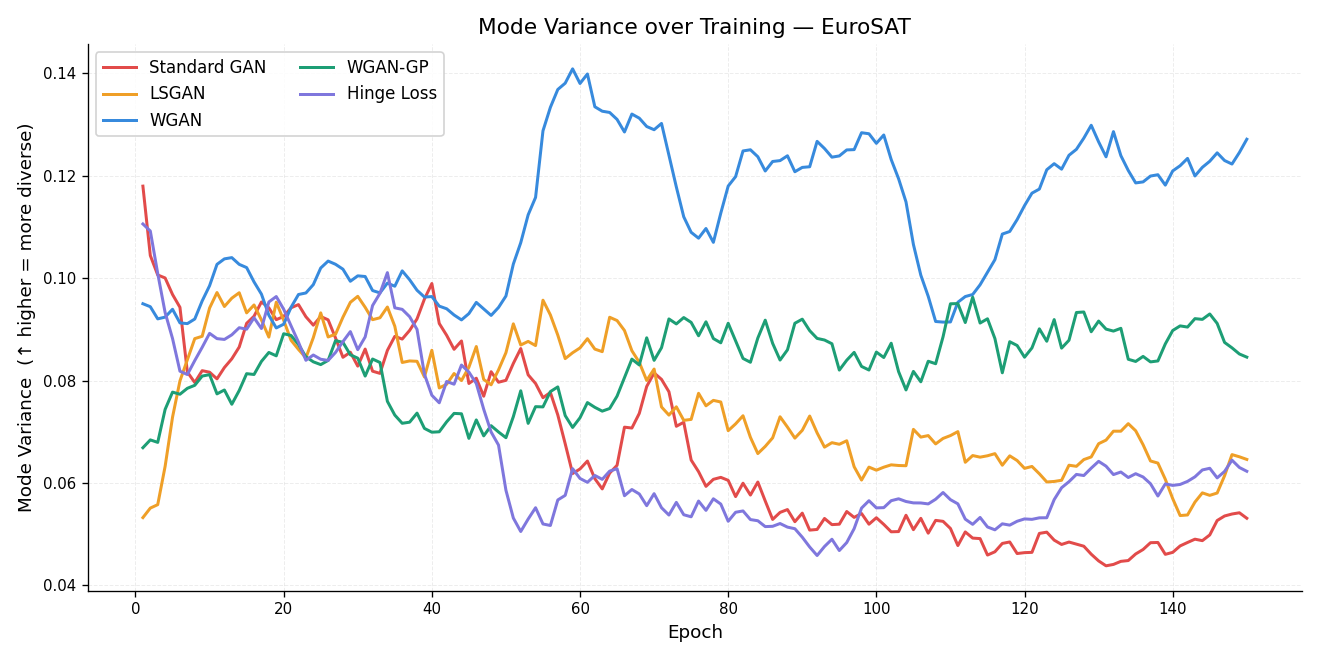

  saved → plots/06_modevar_curves_eurosat.png


In [9]:
# Plot 06 — Mode Variance over epochs · EuroSAT
fig, ax = plt.subplots(figsize=(11, 5.5))

for key in ORDER:
    sub = EURO150[EURO150["Experiment"] == key]
    ep  = sub["Epoch"].tolist()
    mv  = smooth(sub["ModeVar"].tolist(), w=7)
    ax.plot(ep, mv, color=col(key), lw=1.8, label=lbl(key))

ax.set_xlabel("Epoch")
ax.set_ylabel("Mode Variance  (↑ higher = more diverse)")
ax.set_title("Mode Variance over Training — EuroSAT")
ax.legend(fontsize=10, ncol=2, framealpha=0.85)
plt.tight_layout()
plt.show()
save_fig(fig, "06_modevar_curves_eurosat")

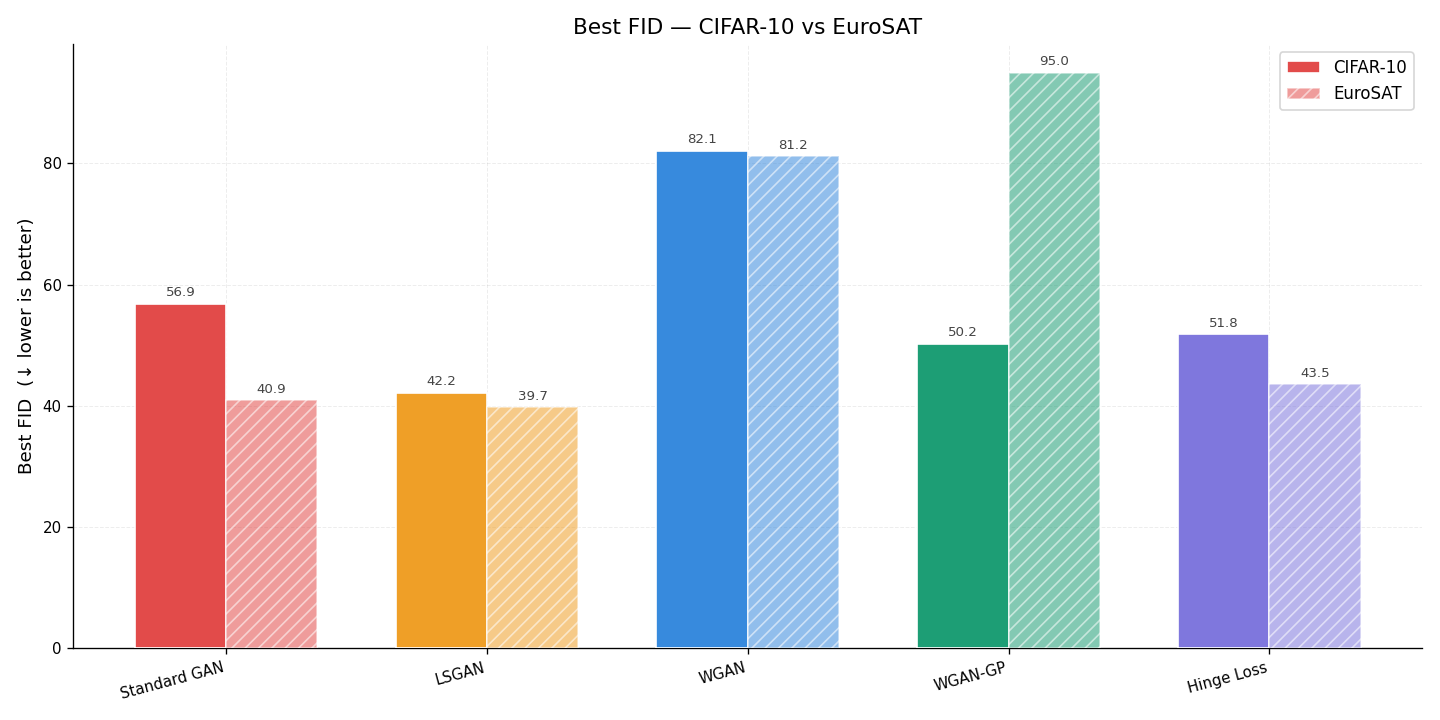

  saved → plots/07_best_fid_comparison.png


In [10]:
# Plot 07 — Best FID bar chart · CIFAR-10 & EuroSAT
best_cifar = {k: min(get_fid(CIFAR,   k)[1]) for k in ORDER}
best_euro  = {k: min(get_fid(EURO150, k)[1]) for k in ORDER}

x = np.arange(len(ORDER))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_c = ax.bar(x - w/2, [best_cifar[k] for k in ORDER], w,
                color=[col(k) for k in ORDER],
                edgecolor="white", zorder=3, label="CIFAR-10")
bars_e = ax.bar(x + w/2, [best_euro[k]  for k in ORDER], w,
                color=[col(k) for k in ORDER],
                edgecolor="white", alpha=0.55, hatch="///", zorder=3,
                label="EuroSAT")

for bar in list(bars_c) + list(bars_e):
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.8,
            f"{v:.1f}", ha="center", va="bottom", fontsize=8, color="#444")

ax.set_xticks(x)
ax.set_xticklabels([LABELS[k] for k in ORDER], rotation=15, ha="right")
ax.set_ylabel("Best FID  (↓ lower is better)")
ax.set_title("Best FID — CIFAR-10 vs EuroSAT")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
save_fig(fig, "07_best_fid_comparison")

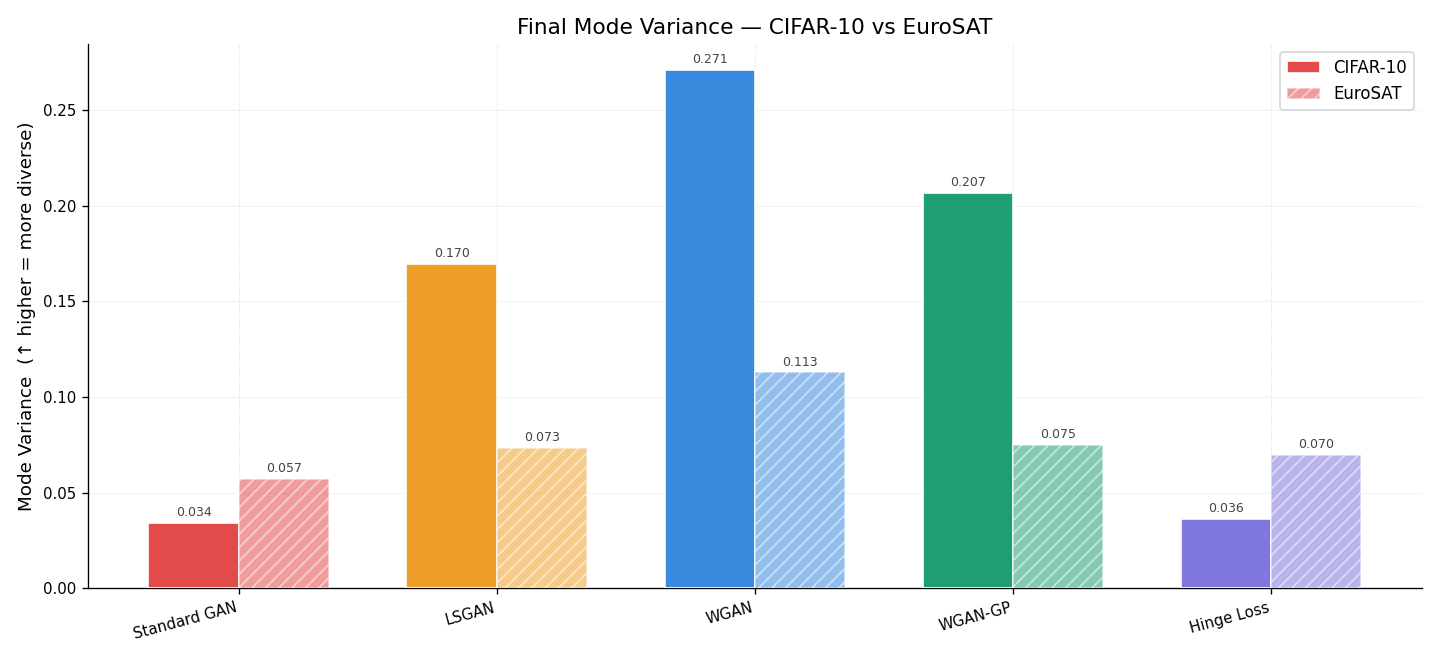

  saved → plots/08_modevar_bar_comparison.png


In [11]:
# Plot 08 — Final Mode Variance bar · CIFAR-10 vs EuroSAT
mc = {k: CIFAR[CIFAR["Experiment"]   == k]["ModeVar"].iloc[-1] for k in ORDER}
me = {k: EURO150[EURO150["Experiment"] == k]["ModeVar"].iloc[-1] for k in ORDER}

x = np.arange(len(ORDER))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5.5))

bars_c = ax.bar(x - w/2, [mc[k] for k in ORDER], w,
                color=[col(k) for k in ORDER],
                edgecolor="white", zorder=3, label="CIFAR-10")
bars_e = ax.bar(x + w/2, [me[k] for k in ORDER], w,
                color=[col(k) for k in ORDER],
                edgecolor="white", alpha=0.55, hatch="///", zorder=3,
                label="EuroSAT")

for bar in list(bars_c) + list(bars_e):
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, color="#444")

ax.set_xticks(x)
ax.set_xticklabels([LABELS[k] for k in ORDER], rotation=15, ha="right")
ax.set_ylabel("Mode Variance  (↑ higher = more diverse)")
ax.set_title("Final Mode Variance — CIFAR-10 vs EuroSAT")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
save_fig(fig, "08_modevar_bar_comparison")

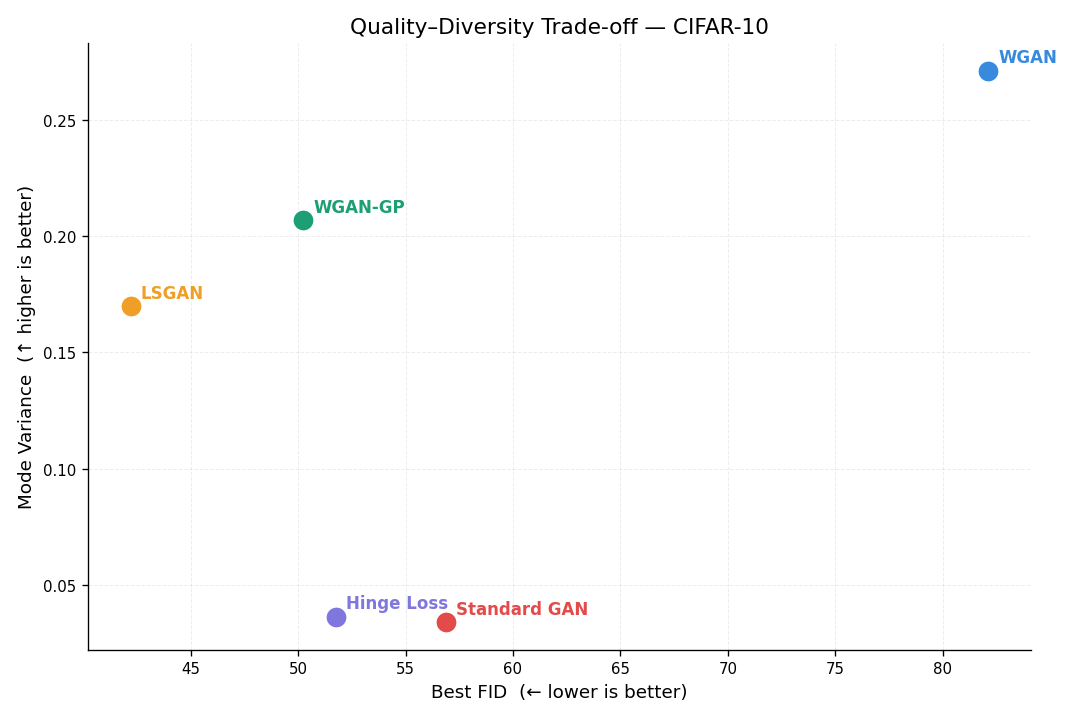

  saved → plots/09_quality_diversity_scatter.png


In [12]:
# Plot 09 — Quality–Diversity Scatter (FID vs ModeVar) · CIFAR-10
bf = {k: min(get_fid(CIFAR, k)[1]) for k in ORDER}
fm = {k: CIFAR[CIFAR["Experiment"] == k]["ModeVar"].iloc[-1] for k in ORDER}

fig, ax = plt.subplots(figsize=(9, 6))

for k in ORDER:
    ax.scatter(bf[k], fm[k],
               color=col(k), s=160,
               marker="o", edgecolors="white", linewidths=0.8, zorder=5)
    ax.annotate(LABELS[k], (bf[k], fm[k]),
                textcoords="offset points",
                xytext=(6, 5), fontsize=10,
                color=col(k), fontweight="bold")

ax.set_xlabel("Best FID  (← lower is better)")
ax.set_ylabel("Mode Variance  (↑ higher is better)")
ax.set_title("Quality–Diversity Trade-off — CIFAR-10")
plt.tight_layout()
plt.show()
save_fig(fig, "09_quality_diversity_scatter")

In [13]:
# ── Run All Plots at Once ────────────────────────────────────────────────────
def run_all():
    sm = lambda a, w=5: uniform_filter1d(np.array(a, dtype=float), size=min(w, len(a)))

    # 01 — FID CIFAR-10
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for k in ORDER:
        ep, fid = get_fid(CIFAR, k)
        ax.plot(ep, fid, color=col(k), lw=1.8, marker="o", markersize=4, label=lbl(k))
    ax.set(xlabel="Epoch", ylabel="FID (↓)", title="FID Curves — CIFAR-10")
    ax.legend(fontsize=10, ncol=2)
    plt.tight_layout(); save_fig(fig, "01_fid_curves_cifar10"); plt.close()

    # 02 — FID EuroSAT
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for k in ORDER:
        ep, fid = get_fid(EURO150, k)
        ax.plot(ep, fid, color=col(k), lw=1.8, marker="o", markersize=4, label=lbl(k))
    ax.set(xlabel="Epoch", ylabel="FID (↓)", title="FID Curves — EuroSAT")
    ax.legend(fontsize=10, ncol=2)
    plt.tight_layout(); save_fig(fig, "02_fid_curves_eurosat"); plt.close()

    # 03 — Loss CIFAR-10
    fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.flatten()
    for ax, k in zip(axes[:5], ORDER):
        ep = CIFAR[CIFAR["Experiment"] == k]["Epoch"].tolist()
        ax.plot(ep, sm(get_col(CIFAR, k, "G_Loss")), color=col(k), lw=2, label="Generator")
        ax.plot(ep, sm(get_col(CIFAR, k, "D_Loss")), color=col(k), lw=1.4, ls="--", alpha=0.6, label="Discriminator")
        ax.set_title(lbl(k), color=col(k), fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=9); ax.set_ylabel("Loss", fontsize=9)
        ax.legend(fontsize=8)
    axes[5].set_visible(False)
    fig.suptitle("Loss Curves — CIFAR-10", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout(); save_fig(fig, "03_loss_curves_cifar10"); plt.close()

    # 04 — Loss EuroSAT
    fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.flatten()
    for ax, k in zip(axes[:5], ORDER):
        s = EURO150[EURO150["Experiment"] == k]
        ep = s["Epoch"].tolist()
        ax.plot(ep, sm(s["G_Loss"].tolist()), color=col(k), lw=2, label="Generator")
        ax.plot(ep, sm(s["D_Loss"].tolist()), color=col(k), lw=1.4, ls="--", alpha=0.6, label="Discriminator")
        ax.set_title(lbl(k), color=col(k), fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=9); ax.set_ylabel("Loss", fontsize=9)
        ax.legend(fontsize=8)
    axes[5].set_visible(False)
    fig.suptitle("Loss Curves — EuroSAT", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout(); save_fig(fig, "04_loss_curves_eurosat"); plt.close()

    # 05 — ModeVar CIFAR-10
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for k in ORDER:
        ep = CIFAR[CIFAR["Experiment"] == k]["Epoch"].tolist()
        ax.plot(ep, sm(get_col(CIFAR, k, "ModeVar"), w=7), color=col(k), lw=1.8, label=lbl(k))
    ax.set(xlabel="Epoch", ylabel="Mode Variance (↑)", title="Mode Variance — CIFAR-10")
    ax.legend(fontsize=10, ncol=2)
    plt.tight_layout(); save_fig(fig, "05_modevar_curves_cifar10"); plt.close()

    # 06 — ModeVar EuroSAT
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for k in ORDER:
        s = EURO150[EURO150["Experiment"] == k]
        ax.plot(s["Epoch"].tolist(), sm(s["ModeVar"].tolist(), w=7), color=col(k), lw=1.8, label=lbl(k))
    ax.set(xlabel="Epoch", ylabel="Mode Variance (↑)", title="Mode Variance — EuroSAT")
    ax.legend(fontsize=10, ncol=2)
    plt.tight_layout(); save_fig(fig, "06_modevar_curves_eurosat"); plt.close()

    # 07 — Best FID bar
    bc = {k: min(get_fid(CIFAR,   k)[1]) for k in ORDER}
    be = {k: min(get_fid(EURO150, k)[1]) for k in ORDER}
    x = np.arange(len(ORDER)); w = 0.35
    fig, ax = plt.subplots(figsize=(12, 6))
    b1 = ax.bar(x-w/2, [bc[k] for k in ORDER], w, color=[col(k) for k in ORDER], edgecolor="white", zorder=3, label="CIFAR-10")
    b2 = ax.bar(x+w/2, [be[k] for k in ORDER], w, color=[col(k) for k in ORDER], edgecolor="white", alpha=0.55, hatch="///", zorder=3, label="EuroSAT")
    for bar in list(b1)+list(b2):
        v = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, v+0.8, f"{v:.1f}", ha="center", va="bottom", fontsize=8, color="#444")
    ax.set_xticks(x); ax.set_xticklabels([LABELS[k] for k in ORDER], rotation=15, ha="right")
    ax.set(ylabel="Best FID (↓)", title="Best FID — CIFAR-10 vs EuroSAT")
    ax.legend(fontsize=10)
    plt.tight_layout(); save_fig(fig, "07_best_fid_comparison"); plt.close()

    # 08 — ModeVar bar
    mc = {k: CIFAR[CIFAR["Experiment"]    == k]["ModeVar"].iloc[-1] for k in ORDER}
    me = {k: EURO150[EURO150["Experiment"] == k]["ModeVar"].iloc[-1] for k in ORDER}
    x = np.arange(len(ORDER)); w = 0.35
    fig, ax = plt.subplots(figsize=(12, 5.5))
    b1 = ax.bar(x-w/2, [mc[k] for k in ORDER], w, color=[col(k) for k in ORDER], edgecolor="white", zorder=3, label="CIFAR-10")
    b2 = ax.bar(x+w/2, [me[k] for k in ORDER], w, color=[col(k) for k in ORDER], edgecolor="white", alpha=0.55, hatch="///", zorder=3, label="EuroSAT")
    for bar in list(b1)+list(b2):
        v = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, v+0.002, f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, color="#444")
    ax.set_xticks(x); ax.set_xticklabels([LABELS[k] for k in ORDER], rotation=15, ha="right")
    ax.set(ylabel="Mode Variance (↑)", title="Final Mode Variance — CIFAR-10 vs EuroSAT")
    ax.legend(fontsize=10)
    plt.tight_layout(); save_fig(fig, "08_modevar_bar_comparison"); plt.close()

    # 09 — Scatter
    bf = {k: min(get_fid(CIFAR, k)[1]) for k in ORDER}
    fm = {k: CIFAR[CIFAR["Experiment"] == k]["ModeVar"].iloc[-1] for k in ORDER}
    fig, ax = plt.subplots(figsize=(9, 6))
    for k in ORDER:
        ax.scatter(bf[k], fm[k], color=col(k), s=160, marker="o",
                   edgecolors="white", linewidths=0.8, zorder=5)
        ax.annotate(LABELS[k], (bf[k], fm[k]), textcoords="offset points",
                    xytext=(6, 5), fontsize=10, color=col(k), fontweight="bold")
    ax.set(xlabel="Best FID (← lower is better)",
           ylabel="Mode Variance (↑ higher is better)",
           title="Quality–Diversity Trade-off — CIFAR-10")
    plt.tight_layout(); save_fig(fig, "09_quality_diversity_scatter"); plt.close()

    print("\n✅ All 9 plots regenerated successfully.")

run_all()

  saved → plots/01_fid_curves_cifar10.png
  saved → plots/02_fid_curves_eurosat.png
  saved → plots/03_loss_curves_cifar10.png
  saved → plots/04_loss_curves_eurosat.png
  saved → plots/05_modevar_curves_cifar10.png
  saved → plots/06_modevar_curves_eurosat.png
  saved → plots/07_best_fid_comparison.png
  saved → plots/08_modevar_bar_comparison.png
  saved → plots/09_quality_diversity_scatter.png

✅ All 9 plots regenerated successfully.


In [18]:
import pandas as pd

files = [
    "cifer_all_6.csv",
    "euro_50epoch.csv",
    "euro_5229_graph.csv",
    "euro_hybrid.csv",
    "hybridloss_cxpert.csv"
]

for f in files:
    try:
        df = pd.read_csv(f"csv/{f}")
        print(f"\n📄 {f}")
        print("Columns:", list(df.columns))
        print("First row:", df.iloc[0].to_dict())
    except Exception as e:
        print(f"Error reading {f}: {e}")


📄 cifer_all_6.csv
Columns: ['Experiment', 'Epoch', 'TotalEpochs', 'G_Loss', 'D_Loss', 'ModeVar', 'FID']
First row: {'Experiment': 'STANDARD', 'Epoch': 1, 'TotalEpochs': 100, 'G_Loss': 6.6416, 'D_Loss': 0.2349, 'ModeVar': 0.174, 'FID': nan}

📄 euro_50epoch.csv
Columns: ['Experiment', 'Epoch', 'TotalEpochs', 'G_Loss', 'D_Loss', 'ModeVar', 'FID']
First row: {'Experiment': 'STANDARD', 'Epoch': 1, 'TotalEpochs': 50, 'G_Loss': 22.9156, 'D_Loss': 0.1021, 'ModeVar': 0.0425, 'FID': nan}

📄 euro_5229_graph.csv
Columns: ['Experiment', 'Epoch', 'TotalEpochs', 'G_Loss', 'D_Loss', 'ModeVar', 'FID']
First row: {'Experiment': 'STANDARD', 'Epoch': 1, 'TotalEpochs': 150, 'G_Loss': 14.1684, 'D_Loss': 0.3058, 'ModeVar': 0.1054, 'FID': nan}

📄 euro_hybrid.csv
Columns: ['Experiment', 'Epoch', 'TotalEpochs', 'G_Loss', 'D_Loss', 'ModeVar', 'FID', 'dataset']
First row: {'Experiment': nan, 'Epoch': 1, 'TotalEpochs': 150, 'G_Loss': 43.5752, 'D_Loss': -15.3683, 'ModeVar': 0.0373, 'FID': nan, 'dataset': 'euro_hyb

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
# Paths (CSV files are inside a "csv" subfolder)
CSV_DIR = Path("csv")
CIFAR_CSV = CSV_DIR / "cifer_all_6.csv"
EURO_CSV = CSV_DIR / "euro_5229_graph.csv"      # 150-epoch final data
CHEX_CSV = CSV_DIR / "hybridloss_cxpert.csv"    # CheXpert data (mostly hybrid, few baselines)

# Baseline losses (case-insensitive)
BASELINE_LOSSES = ["STANDARD", "LSGAN", "WGAN", "WGANGP", "HINGE"]
PRETTY_NAMES = {
    "STANDARD": "Standard GAN",
    "LSGAN": "LSGAN",
    "WGAN": "WGAN",
    "WGANGP": "WGAN-GP",
    "HINGE": "Hinge Loss"
}
ORDER = [PRETTY_NAMES[l] for l in BASELINE_LOSSES]

# Output directory
OUT_DIR = Path("comparison_figures")
OUT_DIR.mkdir(exist_ok=True)

# Colors
COLORS = sns.color_palette("Set2", n_colors=5)

# ============================================================
# 1. Helper: Extract best FID & mode variance from a CSV
# ============================================================
def get_best_results(csv_path, dataset_name):
    if not csv_path.exists():
        print(f"File not found: {csv_path} – using placeholders for {dataset_name}")
        return None
    df = pd.read_csv(csv_path)
    # Filter to baseline losses
    df = df[df['Experiment'].astype(str).str.upper().isin(BASELINE_LOSSES)].copy()
    if df.empty:
        print(f"No baseline losses found in {csv_path} – using placeholders for {dataset_name}")
        return None
    
    results = {}
    for loss in BASELINE_LOSSES:
        sub = df[df['Experiment'].astype(str).str.upper() == loss]
        if sub.empty:
            continue
        # Best FID: ignore NaN and inf
        valid_fid = sub['FID'].replace([np.inf, -np.inf], np.nan).dropna()
        best_fid = valid_fid.min() if not valid_fid.empty else np.nan
        # Mode variance: take last non-NaN value (final epoch)
        valid_mode = sub['ModeVar'].dropna()
        modevar = valid_mode.iloc[-1] if not valid_mode.empty else np.nan
        results[PRETTY_NAMES[loss]] = {'fid': best_fid, 'modevar': modevar}
    return results

# Load real data
cifar_results = get_best_results(CIFAR_CSV, "CIFAR-10")
euro_results = get_best_results(EURO_CSV, "EuroSAT")
chex_results = get_best_results(CHEX_CSV, "CheXpert")

# CheXpert fallback (from your thesis – replace with real baseline numbers when available)
if chex_results is None or len(chex_results) < 5:
    print("\n⚠️ CheXpert baseline results missing. Using placeholder values (replace with real data).")
    chex_results = {
        "Standard GAN": {"fid": 26.04, "modevar": 0.2606},
        "LSGAN": {"fid": 21.34, "modevar": 0.2846},
        "WGAN": {"fid": 59.07, "modevar": 0.3610},
        "WGAN-GP": {"fid": 52.34, "modevar": 0.3780},
        "Hinge Loss": {"fid": 63.21, "modevar": 0.2910}
    }

# Convert to DataFrames
def results_to_df(results):
    df = pd.DataFrame([{"Loss": k, "BestFID": v["fid"], "ModeVar": v["modevar"]} for k, v in results.items()])
    return df

cifar_df = results_to_df(cifar_results)
euro_df = results_to_df(euro_results)
chex_df = results_to_df(chex_results)

# ============================================================
# 2. FID Bar Charts (per dataset)
# ============================================================
def plot_fid_bars(df, dataset_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    sns.barplot(data=df, x="Loss", y="BestFID", order=ORDER, palette=COLORS, ax=ax)
    ax.set_title(f"FID Scores on {dataset_name} (lower is better)")
    ax.set_ylabel("FID ↓")
    ax.set_xlabel("Loss Function")
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(df["BestFID"]):
        ax.text(i, v + max(df["BestFID"])*0.02, f"{v:.2f}", ha='center', va='bottom')
    return ax

fig, axes = plt.subplots(1, 3, figsize=(15,5))
plot_fid_bars(cifar_df, "CIFAR-10", axes[0])
plot_fid_bars(euro_df, "EuroSAT", axes[1])
plot_fid_bars(chex_df, "CheXpert", axes[2])
plt.tight_layout()
plt.savefig(OUT_DIR / "fid_bars_per_dataset.pdf", bbox_inches='tight')
plt.savefig(OUT_DIR / "fid_bars_per_dataset.png", dpi=300, bbox_inches='tight')
plt.close()

# Cross-dataset grouped bar chart
cross_df = pd.concat([
    cifar_df.assign(Dataset="CIFAR-10"),
    euro_df.assign(Dataset="EuroSAT"),
    chex_df.assign(Dataset="CheXpert")
])
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=cross_df, x="Loss", y="BestFID", hue="Dataset", order=ORDER, palette="Set2", ax=ax)
ax.set_title("Cross-Dataset FID Comparison (lower is better)")
ax.set_ylabel("FID ↓")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Dataset")
plt.tight_layout()
plt.savefig(OUT_DIR / "fid_bars_cross_dataset.pdf", bbox_inches='tight')
plt.savefig(OUT_DIR / "fid_bars_cross_dataset.png", dpi=300, bbox_inches='tight')
plt.close()

# ============================================================
# 3. Mode Variance Bar Chart (from CIFAR-10)
# ============================================================
if not cifar_df["ModeVar"].isna().all():
    fig, ax = plt.subplots(figsize=(8,5))
    sns.barplot(data=cifar_df, x="Loss", y="ModeVar", order=ORDER, palette=COLORS, ax=ax)
    ax.set_title("Mode Variance on CIFAR-10 (higher is better – more diversity)")
    ax.set_ylabel("Mode Variance ↑")
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(cifar_df["ModeVar"]):
        ax.text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(OUT_DIR / "mode_variance_bars.pdf", bbox_inches='tight')
    plt.savefig(OUT_DIR / "mode_variance_bars.png", dpi=300, bbox_inches='tight')
    plt.close()
else:
    print("Mode variance data missing – skipping chart.")

# ============================================================
# 4. Training Loss Curves (from epoch-level CSV)
# ============================================================
def plot_loss_curves_from_csv(csv_path, dataset_name):
    if not csv_path.exists():
        print(f"Loss curves file not found: {csv_path}")
        return
    df = pd.read_csv(csv_path)
    df = df[df['Experiment'].astype(str).str.upper().isin(BASELINE_LOSSES)].copy()
    if df.empty:
        print(f"No baseline loss curves in {csv_path}")
        return
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
    for loss in BASELINE_LOSSES:
        sub = df[df['Experiment'].astype(str).str.upper() == loss]
        if sub.empty:
            continue
        pretty = PRETTY_NAMES[loss]
        ax1.plot(sub['Epoch'], sub['G_Loss'], label=pretty)
        ax2.plot(sub['Epoch'], sub['D_Loss'], label=pretty)
    ax1.set_title(f"Generator Loss – {dataset_name}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax2.set_title(f"Discriminator Loss – {dataset_name}")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"loss_curves_{dataset_name.lower()}.pdf", bbox_inches='tight')
    plt.savefig(OUT_DIR / f"loss_curves_{dataset_name.lower()}.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved loss curves for {dataset_name}")

# Generate loss curves from available epoch data
plot_loss_curves_from_csv(CIFAR_CSV, "CIFAR-10")
plot_loss_curves_from_csv(EURO_CSV, "EuroSAT")

# CheXpert loss curves (if baseline epoch data exists)
try:
    df_chex = pd.read_csv(CHEX_CSV)
    if any(df_chex['Experiment'].astype(str).str.upper().isin(BASELINE_LOSSES)):
        plot_loss_curves_from_csv(CHEX_CSV, "CheXpert")
    else:
        print("No baseline epoch data in CheXpert CSV – skipping loss curves.")
except:
    print("CheXpert loss curves skipped.")

# ============================================================
# 5. Generate LaTeX Table Code
# ============================================================
def latex_table(df, caption, label):
    lines = []
    lines.append("\\begin{table}[htbp]")
    lines.append("\\centering")
    lines.append("\\caption{" + caption + "}")
    lines.append("\\label{" + label + "}")
    lines.append("\\begin{tabular}{lcc}")
    lines.append("\\toprule")
    lines.append("Loss Function & Best FID $\\downarrow$ & Mode Variance $\\uparrow$ \\\\")
    lines.append("\\midrule")
    for _, row in df.iterrows():
        fid_str = f"{row['BestFID']:.2f}" if not pd.isna(row['BestFID']) else "---"
        mode_str = f"{row['ModeVar']:.4f}" if not pd.isna(row['ModeVar']) else "---"
        lines.append(f"{row['Loss']} & {fid_str} & {mode_str} \\\\")
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append("\\end{table}")
    return "\n".join(lines)

print("\n" + "="*60)
print("LATEX TABLE CODE – COPY INTO YOUR THESIS")
print("="*60)
print(latex_table(cifar_df, "Quantitative evaluation on CIFAR-10 (five baselines).", "tab:cifar10_baselines"))
print("\n" + "-"*60 + "\n")
print(latex_table(euro_df, "Quantitative evaluation on EuroSAT (five baselines).", "tab:eurosat_baselines"))
print("\n" + "-"*60 + "\n")
print(latex_table(chex_df, "Quantitative evaluation on CheXpert (five baselines).", "tab:chexpert_baselines"))

# ============================================================
# 6. Placeholder Qualitative Grids
# ============================================================
def placeholder_grid(dataset_name):
    fig, axes = plt.subplots(2, 5, figsize=(10,4))
    for i, loss in enumerate(ORDER):
        ax = axes[0, i] if i < 5 else axes[1, i-5]
        ax.text(0.5, 0.5, loss, ha='center', va='center', fontsize=10)
        ax.axis('off')
    plt.suptitle(f"Generated samples on {dataset_name} (replace with actual images)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"qualitative_{dataset_name.lower().replace('-','_')}_placeholder.pdf", bbox_inches='tight')
    plt.savefig(OUT_DIR / f"qualitative_{dataset_name.lower().replace('-','_')}_placeholder.png", dpi=300, bbox_inches='tight')
    plt.close()

for ds in ["CIFAR-10", "EuroSAT", "CheXpert"]:
    placeholder_grid(ds)

print("\n" + "="*60)
print(f"All figures saved in: {OUT_DIR.absolute()}")
print("Remember to replace placeholder grids with your actual generated images.")

No baseline losses found in csv\hybridloss_cxpert.csv – using placeholders for CheXpert

⚠️ CheXpert baseline results missing. Using placeholder values (replace with real data).
Saved loss curves for CIFAR-10
Saved loss curves for EuroSAT
No baseline epoch data in CheXpert CSV – skipping loss curves.

LATEX TABLE CODE – COPY INTO YOUR THESIS
\begin{table}[htbp]
\centering
\caption{Quantitative evaluation on CIFAR-10 (five baselines).}
\label{tab:cifar10_baselines}
\begin{tabular}{lcc}
\toprule
Loss Function & Best FID $\downarrow$ & Mode Variance $\uparrow$ \\
\midrule
Standard GAN & 56.86 & 0.0341 \\
LSGAN & 42.20 & 0.1698 \\
WGAN & 82.12 & 0.2711 \\
WGAN-GP & 50.24 & 0.2067 \\
Hinge Loss & 51.78 & 0.0364 \\
\bottomrule
\end{tabular}
\end{table}

------------------------------------------------------------

\begin{table}[htbp]
\centering
\caption{Quantitative evaluation on EuroSAT (five baselines).}
\label{tab:eurosat_baselines}
\begin{tabular}{lcc}
\toprule
Loss Function & Best FID $